In [9]:
import os
import struct
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [10]:
batch_size    = 64
noise_dim     = 100
learning_rate = 0.0002
num_epochs    = 20

train_path = "/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte"

In [11]:
def load_mnist_images(file_path):
    """Read MNIST .idx3-ubyte file -> tensor [N, 28, 28]"""
    with open(file_path, "rb") as f:
        _, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    images = data.reshape(num_images, rows, cols)
    return torch.tensor(images, dtype=torch.float32)


def normalize(images):
    """Scale pixels from [0, 255] -> [-1, 1] (matches Generator's Tanh output)"""
    return (images / 255.0) * 2 - 1


class MNISTDataset(Dataset):
    def __init__(self, file_path):
        self.images = normalize(load_mnist_images(file_path))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx].unsqueeze(0)   # [28,28] -> [1,28,28]


train_dataset = MNISTDataset(train_path)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print("Total images:", len(train_dataset))

Total images: 60000


In [12]:
class Generator(nn.Module):
    """Noise (100) -> fake image (1x28x28)"""
    def __init__(self, noise_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),       nn.ReLU(),
            nn.Linear(512, 784),       nn.Tanh(),   # output in [-1, 1]
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    """Image (1x28x28) -> one score (real vs fake)"""
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1),   # no Sigmoid: BCEWithLogitsLoss handles it
        )

    def forward(self, x):
        return self.model(x.view(-1, 784))


G = Generator(noise_dim).to(device)
D = Discriminator().to(device)

In [13]:
criterion   = nn.BCEWithLogitsLoss()
optimizer_G = optim.Adam(G.parameters(), lr=learning_rate, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=learning_rate, betas=(0.5, 0.999))

In [14]:
for epoch in range(num_epochs):
    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")
    total_D_loss, total_G_loss = 0.0, 0.0

    for real_images in progress_bar:
        real_images = real_images.to(device)
        bs = real_images.size(0)

        real_labels = torch.ones(bs, 1, device=device)    # real = 1
        fake_labels = torch.zeros(bs, 1, device=device)   # fake = 0

        # ---------- Train Discriminator ----------
        z = torch.randn(bs, noise_dim, device=device)
        fake_images = G(z)

        loss_real = criterion(D(real_images), real_labels)
        loss_fake = criterion(D(fake_images.detach()), fake_labels)  # detach: don't update G here
        loss_D = loss_real + loss_fake

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # ---------- Train Generator ----------
        z = torch.randn(bs, noise_dim, device=device)
        fake_images = G(z)

        loss_G = criterion(D(fake_images), real_labels)   # G wants D to say "real"

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        # ---------- Logging ----------
        total_D_loss += loss_D.item()
        total_G_loss += loss_G.item()
        progress_bar.set_postfix(loss_D=f"{loss_D.item():.4f}",
                                 loss_G=f"{loss_G.item():.4f}")

    print(f"Epoch {epoch+1}: "
          f"D loss = {total_D_loss/len(train_loader):.4f}, "
          f"G loss = {total_G_loss/len(train_loader):.4f}")

    # Save after each epoch
    torch.save(G.state_dict(), "generator_last.pth")
    torch.save(D.state_dict(), "discriminator_last.pth")

Epoch [1/20]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1: D loss = 0.6740, G loss = 2.4013


Epoch [2/20]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2: D loss = 0.3721, G loss = 3.7034


Epoch [3/20]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 18: D loss = 0.9252, G loss = 1.4580


Epoch [19/20]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 19: D loss = 0.9324, G loss = 1.4475


Epoch [20/20]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 20: D loss = 0.9394, G loss = 1.4342


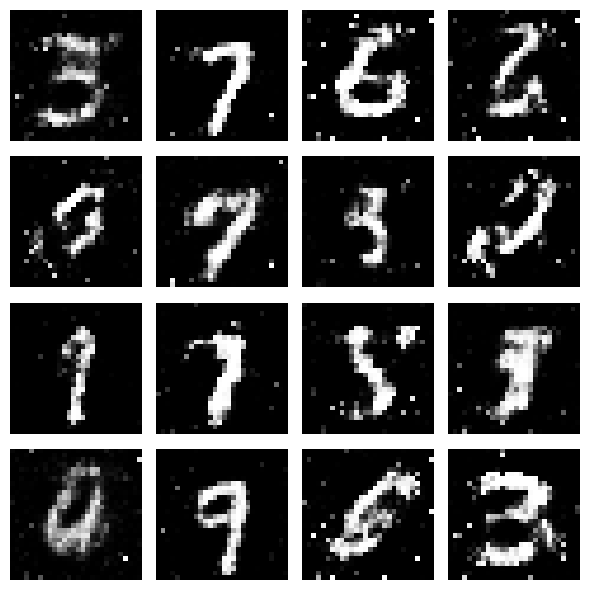

In [15]:
G = Generator(noise_dim).to(device)
G.load_state_dict(torch.load("generator_last.pth", map_location=device))
G.eval()

z = torch.randn(16, noise_dim, device=device)
with torch.no_grad():
    fake_images = (G(z) + 1) / 2     # [-1,1] -> [0,1]

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for img, ax in zip(fake_images, axes.flatten()):
    ax.imshow(img.cpu().squeeze(), cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()